   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

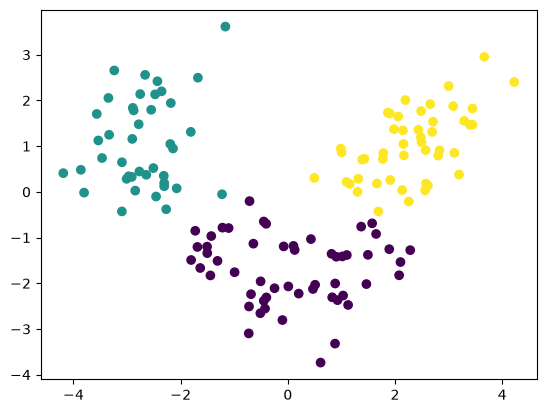

3


In [ ]:
#PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator

df=load_wine(as_frame=True).frame
print(df.head())

X = df.drop("target", axis=1)
y=df["target"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model=PCA(
    n_components=2,
    random_state=42
)
X_train_pca=model.fit_transform(X_train_scaled)
X_test_pca=model.transform(X_test_scaled)

print("explained variance",model.explained_variance_ratio_)
wcss=[]
for k in range(1,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )
    kmeans.fit(X_train_pca)
    wcss.append(kmeans.inertia_)
k_values=range(1,11) 
knee=KneeLocator(
    k_values,
    wcss,
    curve="convex",
    direction="decreasing"
)
best_k=knee.elbow
kmeans=KMeans(
        n_clusters=best_k,
        random_state=42
    )
labels=kmeans.fit_predict(X_train_pca)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],c=labels)
plt.show()
print(df["target"].nunique()) #total unique values


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

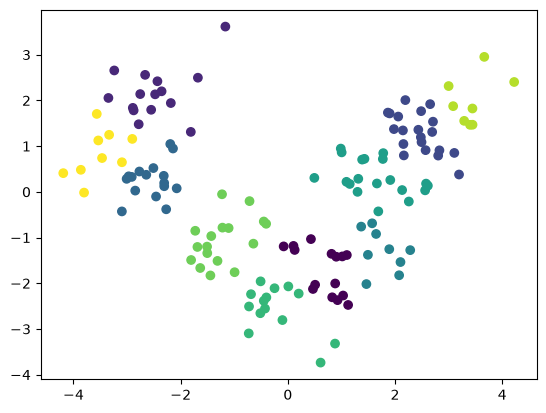

3


In [19]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

df=load_wine(as_frame=True).frame
print(df.head())

X = df.drop("target", axis=1)
y=df["target"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model=PCA(
    n_components=2,
    random_state=42
)
X_train_pca=model.fit_transform(X_train_scaled)
X_test_pca=model.transform(X_test_scaled)

print("explained variance",model.explained_variance_ratio_)

k_values=range(2,11)
for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42
    )
    labels=model.fit_predict(X_train_pca) 
    score=silhouette_score(X_train_pca,labels)
    print("K =", k, "Silhouette Score =", score)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],c=labels)
plt.show()
print(df["target"].nunique()) #total unique values
